In [ ]:
import sys
sys.path.append('..')

from Agent.config import LLM, SMALL_LLM, SMART_LLM, EMBEDDING

In [2]:
query = '대손충당금에 대해서 설명해주세요'

In [7]:
from typing import Annotated                # 메타데이터(langgraph가 받을) 다는 라이브러리
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [8]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [9]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = SMALL_LLM.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

In [10]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [11]:
graph = graph_builder.compile()

In [12]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

In [13]:
graph.invoke(initial_state)

{'messages': [HumanMessage(content='대손충당금에 대해서 설명해주세요', additional_kwargs={}, response_metadata={}, id='1030b852-c580-4cf3-93b5-da23262b5aff'),
  AIMessage(content='# 대손충당금(Allowance for Doubtful Accounts)\n\n## 📌 개념\n기업이 외상으로 판매한 상품이나 대여금 등의 채권 중에서 **회수하지 못할 가능성이 있는 부분**을 미리 예상하여 적립하는 충당금입니다.\n\n---\n\n## 🎯 목적\n\n| 목적 | 설명 |\n|------|------|\n| **보수주의 원칙** | 손실 가능성을 미리 인식 |\n| **재무제표 신뢰성** | 자산을 실제 가치에 가깝게 표시 |\n| **손실 대비** | 예상 손실에 대한 준비 |\n\n---\n\n## 💰 회계처리\n\n### 1) **충당금 설정 시**\n```\n차변: 대손상각비 (비용)\n  대변: 대손충당금 (자산차감)\n```\n\n### 2) **실제 대손 발생 시**\n```\n차변: 대손충당금 (충당금 감소)\n  대변: 외상매출금 (채권 제거)\n```\n\n---\n\n## 📊 계산 방법\n\n### ① **매출액 비율법** (가장 일반적)\n```\n대손충당금 = 매출액 × 대손률(%)\n예: 매출액 1억 원 × 1% = 100만 원\n```\n\n### ② **외상매출금 비율법**\n```\n대손충당금 = 외상매출금 × 대손률(%)\n```\n\n### ③ **개별 평가법**\n각 채권의 회수 가능성을 개별적으로 평가\n\n---\n\n## 📈 재무제표 표시\n\n**대차대조표(자산 부분)**\n```\n유동자산\n  외상매출금          10,000,000원\n  대손충당금            (100,000)원\n  순 외상매출금       9,900,000원\n```\n\n---\n\n## ✅ 예시\n\n**상황**: 연

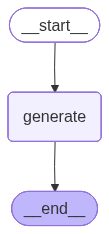

In [14]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## 데이터 전처리

In [ ]:
# import nest_asyncio
# nest_asyncio.apply()

In [ ]:
# from pyzerox import zerox
# import os
# import asyncio
# from dotenv import load_dotenv

# load_dotenv()


# model = "claude-sonnet-4-20250514"
# custom_system_prompt = None

# async def main():
#     file_path = "Tax.pdf"
#     select_pages = None  # 전체 페이지
#     output_dir = "./output_test"
    
#     result = await zerox(
#         file_path=file_path,
#         model=model,
#         output_dir=output_dir,
#         custom_system_prompt=custom_system_prompt,
#         select_pages=select_pages
#     )
#     return result

# # 실행
# result = asyncio.run(main())
# print(result)

## Retrieve

In [ ]:
# from langchain_upstage import UpstageEmbeddings
# from langchain_chroma import Chroma
# from langchain_community.document_loaders import Docx2txtLoader
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# import shutil

# # 1. 문서 로드
# loader = Docx2txtLoader('Tax_with_table.docx')
# documents = loader.load()

# # 2. 텍스트 분할 (청킹)
# text_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=1000,
#     chunk_overlap=200
# )
# splits = text_splitter.split_documents(documents)

In [26]:
from langchain_chroma import Chroma


# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= '../db/by-article-upstage',
  embedding_function= EMBEDDING     
)

In [27]:
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,                # chunk_size 고려해서 조정 - 추후 context history까지 관리해야 함
        'fetch_k': 50,          # 나중엔 동적 k / 히스토리 요약으로 구현하고 싶음
        'lamda_mult': 0.6       # simility와 가까운 수준(mmr에서)
    }
)

In [28]:
query = '원천징수되는 기타소득에 관하여 설명하시오'

result =retriever.invoke(query)

result

[Document(metadata={'article': '제145조', 'chapter': '제5장', 'effective_date': '20251001', 'paragraph': 1, 'section': '제1절', 'source': '소득세법', 'subsection': '제5관', 'title': '(기타소득에 대한 원천징수시기와 방법 및 원천징수영수증의 발급)'}, page_content='제145조(기타소득에 대한 원천징수시기와 방법 및 원천징수영수증의 발급) ① 원천징수의무자가 기타소득을 지급할 때에는 그 기타소득금액에 원천징수세율을 적용하여 계산한 소득세를 원천징수한다.'),
 Document(metadata={'article': '제129조', 'chapter': '제5장', 'effective_date': '20251001', 'ho_range': '6~6호', 'paragraph': 1, 'section': '제1절', 'source': '소득세법', 'subsection': '제1관', 'title': '(원천징수세율)'}, page_content='제129조(원천징수세율) ①\n6. 기타소득에 대해서는 다음에 규정하는 세율. 다만, 제8호를 적용받는 경우는 제외한다.\n가. 제14조제3항제8호라목 및 마목에 해당하는 소득금액이 3억원을 초과하는 경우 그 초과하는 분에 대해서는 100분의 30\n나. 제21조제1항제18호 및 제21호에 따른 기타소득에 대해서는 100분의 15\n다. 삭제 <2014.12.23>\n라. 그 밖의 기타소득에 대해서는 100분의 20'),
 Document(metadata={'article': '제21조', 'chapter': '제2장', 'effective_date': '20251001', 'ho_range': '1~3호', 'paragraph': 1, 'section': '제2절', 'source': '소득세법', 'subsection': '제2관', 'title': '(기타소득)'}, page_content

## RAG Chain with Node, Edge

In [29]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [34]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

In [35]:
def retrieve(state: AgentState):
    query  = state['query']         # state의 query를 받아서 
    docs = retriever.invoke(query)  # retrieve 하고
    return {'context': docs}        # 그걸 context에 넣어서 toss~

In [36]:
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | SMART_LLM
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response}

In [37]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [38]:
from langgraph.graph import START, END

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [39]:
graph = graph_builder.compile()

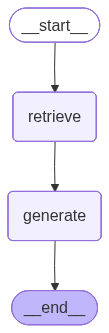

In [40]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## RAG Chain with Sequence

In [14]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [15]:
sequence_graph_builder.add_edge(START, 'retrieve')      # add_sequence에서 함수 이름으로 Node를 만들어놓고 그 사이의 edge도 그어줌
sequence_graph_builder.add_edge('generate', END)

In [16]:
graph = sequence_graph_builder.compile()

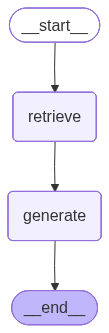

In [17]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
query = '8000만원에 매도한 서화가 기타소득 과세 대상인지 알려줘'
initial_state = {'query': query}
result = graph.invoke(initial_state)
display(Markdown(result['answer'].content))

8000만원에 매도한 서화의 기타소득 과세 여부에 대해 답변드립니다.

소득세법 제21조 제2항에 따르면, 대통령령으로 정하는 서화·골동품의 양도로 발생하는 소득은 기타소득에 해당합니다. 다만, 제12조 제5호에 따라 **국가지정문화유산으로 지정된 서화·골동품의 양도소득**이나 **박물관 또는 미술관에 양도하는 경우**는 비과세됩니다.

따라서 8000만원에 매도한 서화가 국가지정문화유산이 아니고, 박물관·미술관이 아닌 곳에 양도한 경우라면 **기타소득 과세 대상**이 됩니다.